In [ ]:
import os
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath(""))
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
os.chdir(ROOT_DIR)

print(f"Рабочая директория: {Path.cwd()}")
print(f"Содержимое: {[p.name for p in Path.cwd().iterdir()]}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

PROCESSED_DIR = Path("data/processed")
RAW_DIR       = Path("data/raw")
IMAGES_DIR    = Path("report/images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


Рабочая директория: /content
Содержимое: ['.config', 'models', 'data', 'report', 'sample_data']


In [ ]:
df = pd.read_csv(PROCESSED_DIR / "features.csv", index_col="date", parse_dates=True)

if df.index.tz is not None:
    df.index = df.index.tz_localize(None)

print(f"Форма датасета: {df.shape}")
print(f"Период: {df.index.min().date()} — {df.index.max().date()}")
print(f"Тикеров: {df['ticker'].nunique()}")
print(f"\nКолонки:\n{df.columns.tolist()}")

Форма датасета: (148409, 43)
Период: 2018-03-14 — 2023-12-21
Тикеров: 102

Колонки:
['open', 'high', 'low', 'close', 'volume', 'ticker', 'sma_10', 'sma_10_ratio', 'sma_20', 'sma_20_ratio', 'sma_50', 'sma_50_ratio', 'ema_12', 'ema_26', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'roc_5', 'roc_10', 'roc_20', 'bb_mid', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'atr', 'atr_ratio', 'hvol_10', 'hvol_20', 'obv', 'volume_sma', 'volume_sma_ratio', 'volume_change', 'body_size', 'upper_shadow', 'lower_shadow', 'is_bullish', 'target', 'day_of_week', 'month', 'quarter', 'is_month_end']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 148409 entries, 2018-03-14 to 2023-12-21
Data columns (total 43 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   open              148409 non-null  float64
 1   high              148409 non-null  float64
 2   low               148409 non-null  float64
 3   close             148409 non-null  float64
 4   volume            148409 non-null  int64  
 5   ticker            148409 non-null  object 
 6   sma_10            148409 non-null  float64
 7   sma_10_ratio      148409 non-null  float64
 8   sma_20            148409 non-null  float64
 9   sma_20_ratio      148409 non-null  float64
 10  sma_50            148409 non-null  float64
 11  sma_50_ratio      148409 non-null  float64
 12  ema_12            148409 non-null  float64
 13  ema_26            148409 non-null  float64
 14  rsi               148409 non-null  float64
 15  macd              148409 non-null  float64
 16  macd

In [ ]:
na_stats = df.isna().sum()
na_stats = na_stats[na_stats > 0]

if na_stats.empty:
    print("Пропусков нет")
else:
    print("Колонки с пропусками:")
    print(na_stats)

Пропусков нет


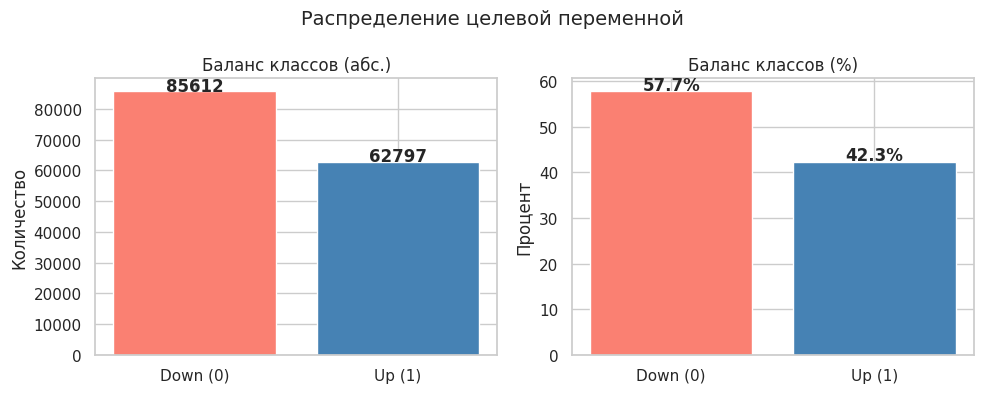


Класс 0 (Down): 85612 (57.7%)
Класс 1 (Up):   62797 (42.3%)


In [ ]:
# Баланс классов
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Абсолютные значения
counts = df["target"].value_counts()
axes[0].bar(["Down (0)", "Up (1)"], counts.values, color=["salmon", "steelblue"])
axes[0].set_title("Баланс классов (абс.)")
axes[0].set_ylabel("Количество")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Относительные значения
pcts = df["target"].value_counts(normalize=True) * 100
axes[1].bar(["Down (0)", "Up (1)"], pcts.values, color=["salmon", "steelblue"])
axes[1].set_title("Баланс классов (%)")
axes[1].set_ylabel("Процент")
for i, v in enumerate(pcts.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Распределение целевой переменной", fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "target_balance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nКласс 0 (Down): {counts[0]} ({pcts[0]:.1f}%)")
print(f"Класс 1 (Up):   {counts[1]} ({pcts[1]:.1f}%)")

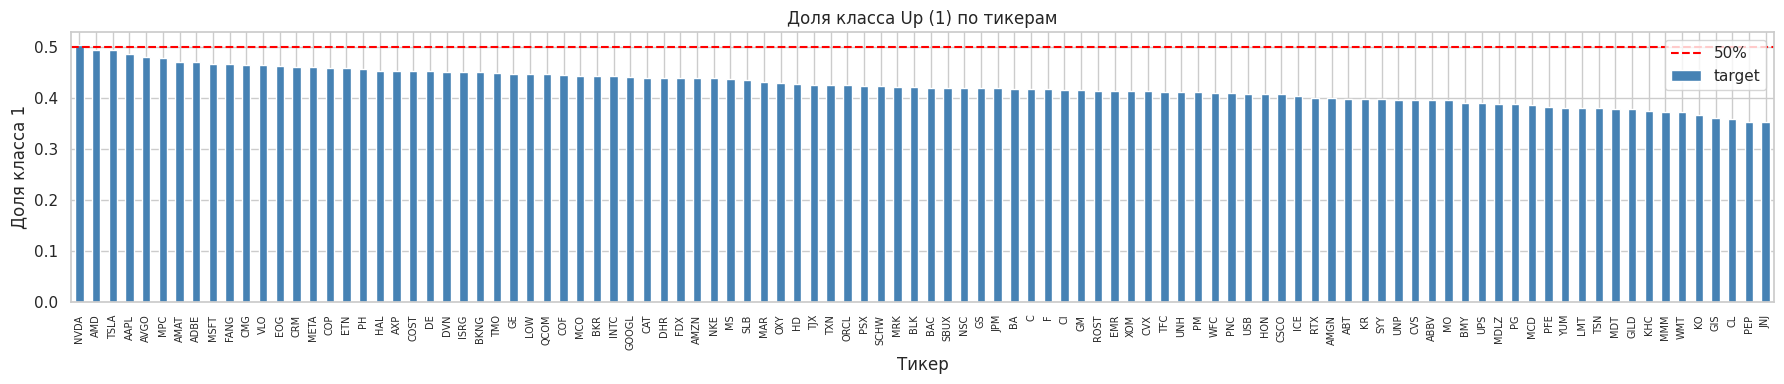

In [ ]:
# Распределение таргета по тикерам
ticker_target = (
    df.groupby("ticker")["target"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(18, 4))
ticker_target.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(0.5, color="red", linestyle="--", label="50%")
ax.set_title("Доля класса Up (1) по тикерам")
ax.set_ylabel("Доля класса 1")
ax.set_xlabel("Тикер")
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "target_by_ticker.png", dpi=150, bbox_inches="tight")
plt.show()

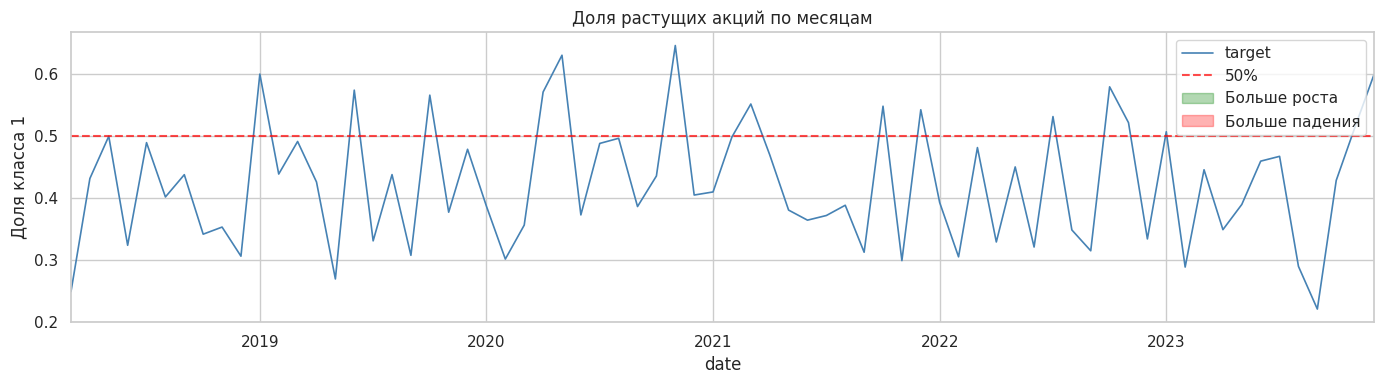

In [ ]:
# Распределение таргета по времени (по месяцам)
monthly = df.groupby(df.index.to_period("M"))["target"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, color="steelblue", linewidth=1.2)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="50%")
ax.fill_between(range(len(monthly)), monthly.values, 0.5,
                where=monthly.values >= 0.5, alpha=0.3, color="green", label="Больше роста")
ax.fill_between(range(len(monthly)), monthly.values, 0.5,
                where=monthly.values < 0.5, alpha=0.3, color="red", label="Больше падения")
ax.set_title("Доля растущих акций по месяцам")
ax.set_ylabel("Доля класса 1")
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "target_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

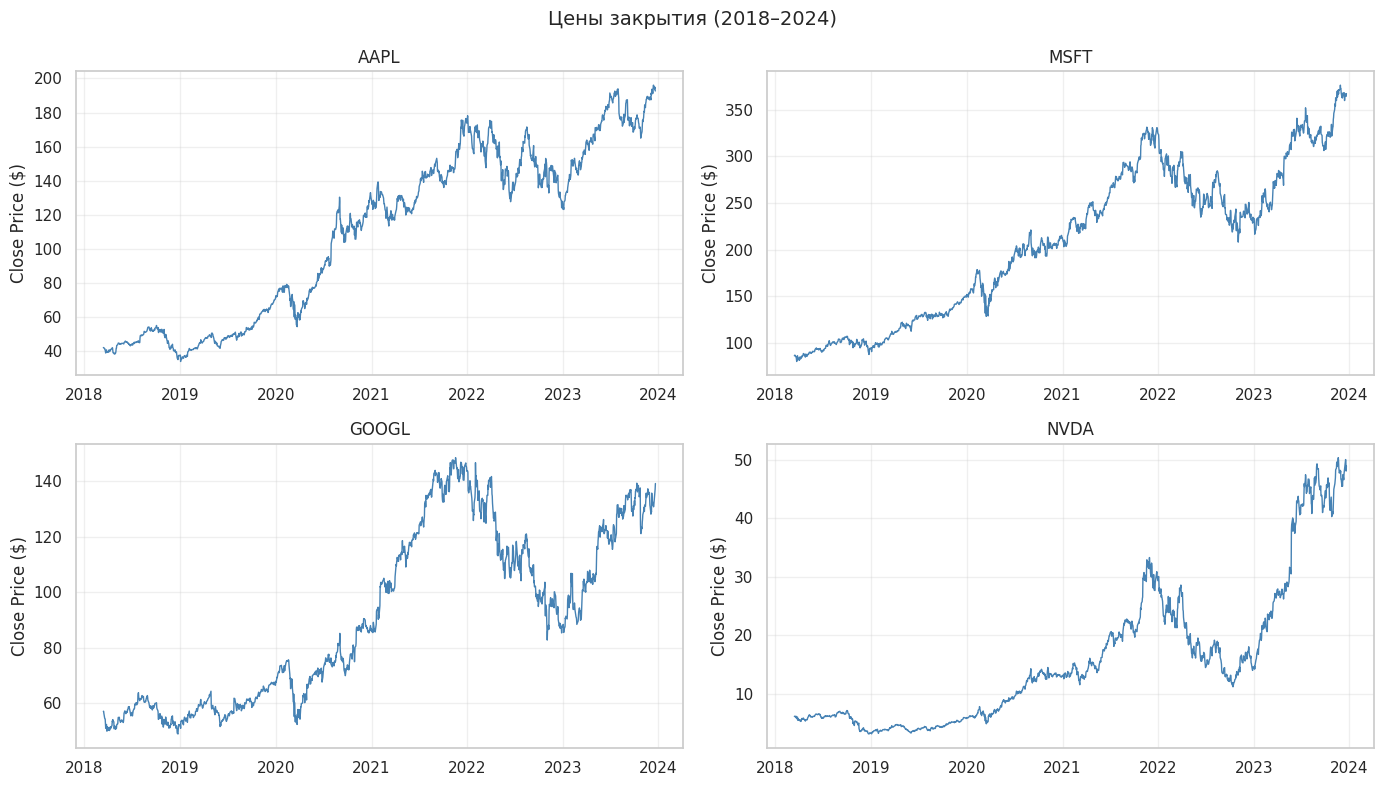

In [ ]:
# Пример ценового графика для нескольких тикеров
sample_tickers = ["AAPL", "MSFT", "GOOGL", "NVDA"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(sample_tickers):
    subset = df[df["ticker"] == ticker]["close"]
    axes[i].plot(subset.index, subset.values, linewidth=1, color="steelblue")
    axes[i].set_title(ticker)
    axes[i].set_ylabel("Close Price ($)")
    axes[i].grid(alpha=0.3)

plt.suptitle("Цены закрытия (2018–2024)", fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "price_charts.png", dpi=150, bbox_inches="tight")
plt.show()

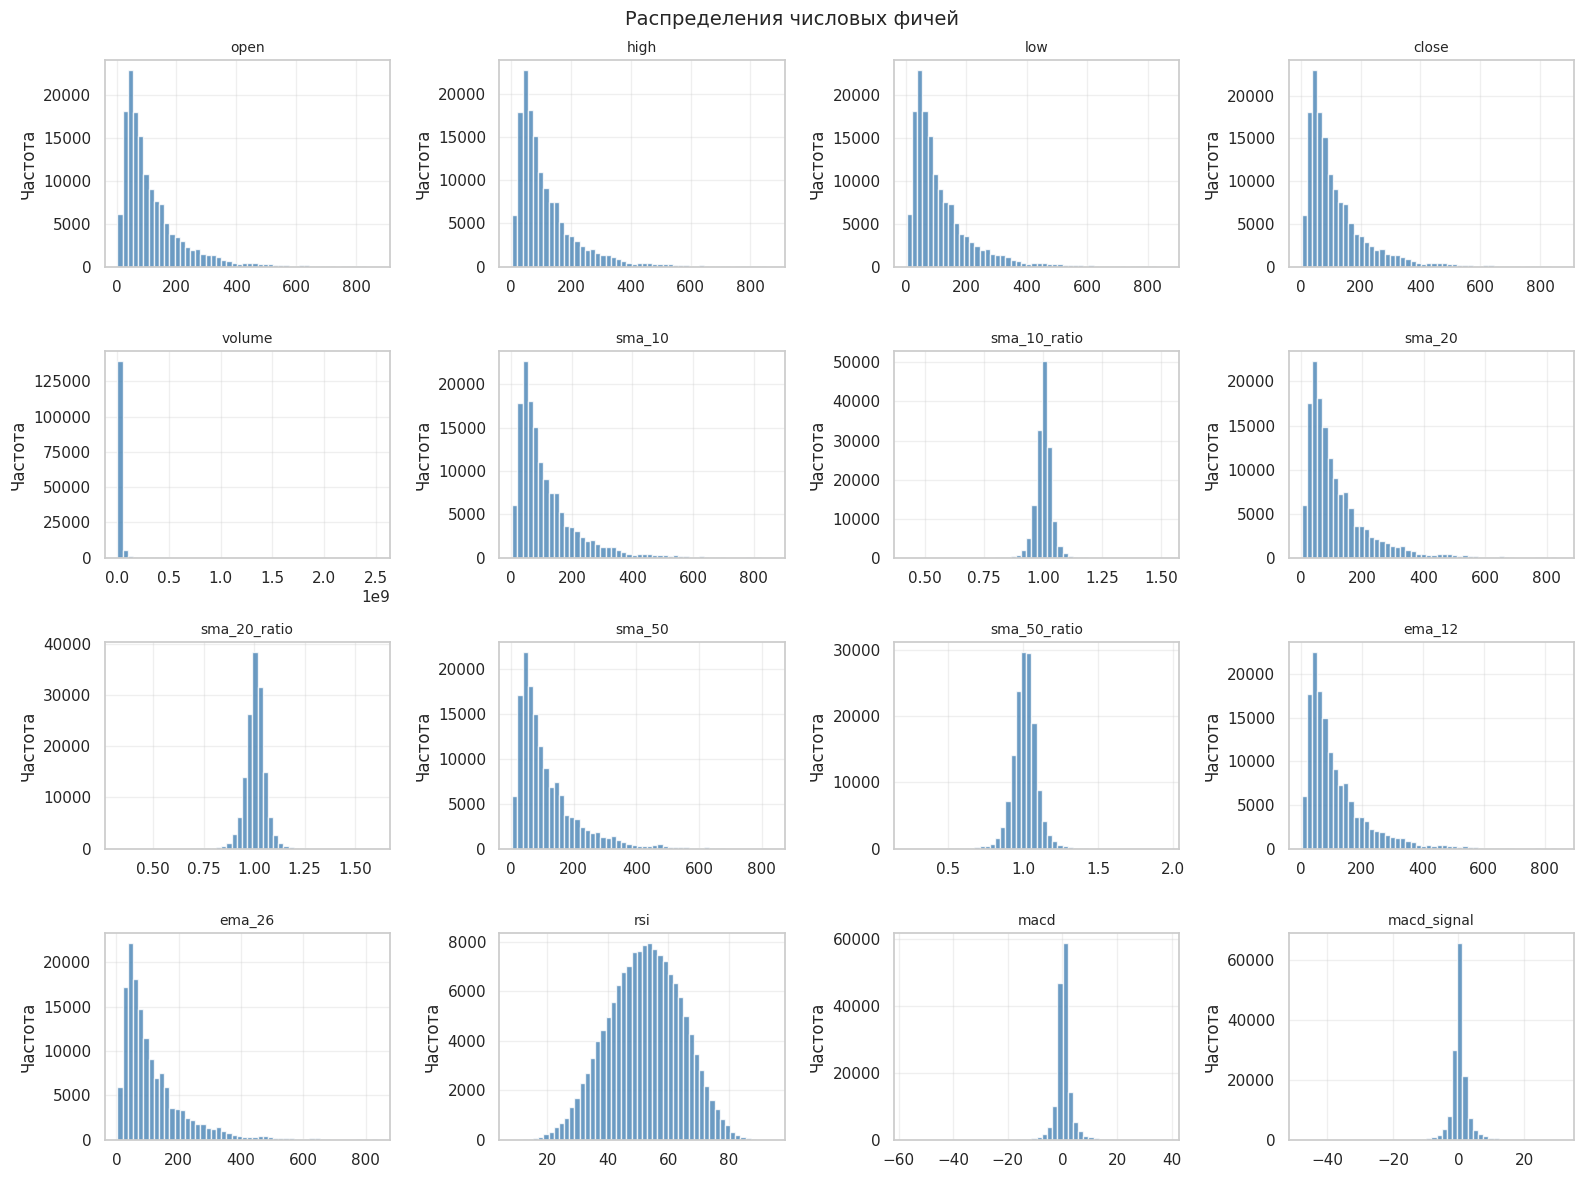

In [ ]:
# Распределения числовых фичей
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["target"]]

# первые 16 фичей для отображения
cols_to_plot = numeric_cols[:16]
n_cols = 4
n_rows = len(cols_to_plot) // n_cols + int(len(cols_to_plot) % n_cols != 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Частота")
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Распределения числовых фичей", fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

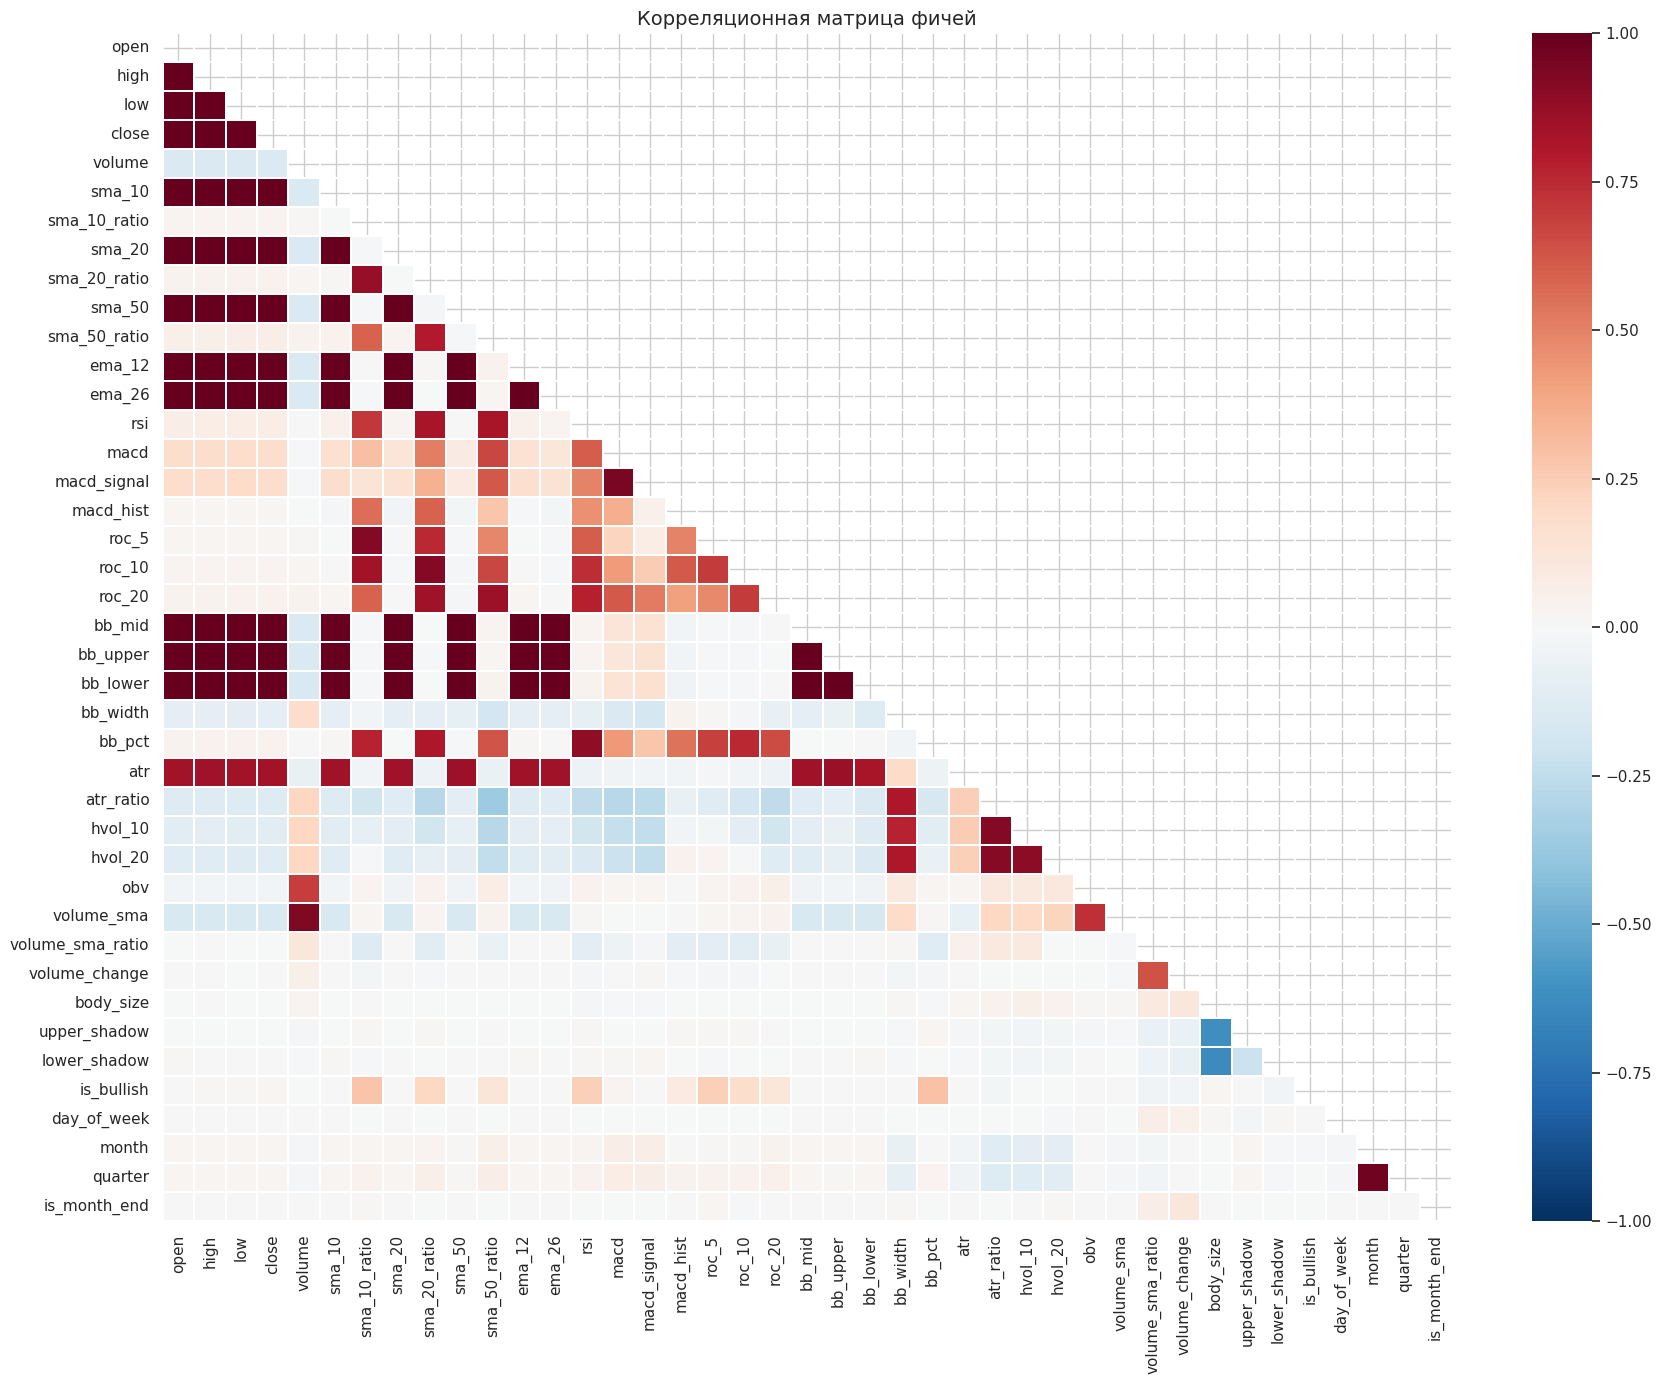

In [ ]:
feature_cols = [c for c in numeric_cols if c not in ["target"]]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Корреляционная матрица фичей", fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Топ коррелирующих пар для выявления мультиколлинеарности)
corr_pairs = (
    corr.where(mask == False)  # noqa: E712
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
corr_pairs = corr_pairs[corr_pairs["feature_1"] != corr_pairs["feature_2"]]

print("Топ-15 сильно коррелирующих пар (|corr| > 0.8)")
high_corr = corr_pairs[corr_pairs["abs_corr"] > 0.8].sort_values("abs_corr", ascending=False)
print(high_corr.head(15).to_string(index=False))

Топ-15 сильно коррелирующих пар (|corr| > 0.8)
feature_1 feature_2  correlation  abs_corr
   bb_mid    sma_20       1.0000    1.0000
   ema_12    sma_10       0.9999    0.9999
     high      open       0.9999    0.9999
    close       low       0.9999    0.9999
    close      high       0.9999    0.9999
      low      open       0.9999    0.9999
   bb_mid    ema_26       0.9998    0.9998
   ema_26    sma_20       0.9998    0.9998
      low      high       0.9998    0.9998
    close      open       0.9997    0.9997
   bb_mid    ema_12       0.9996    0.9996
   ema_12    sma_20       0.9996    0.9996
   ema_26    ema_12       0.9995    0.9995
   sma_20    sma_10       0.9994    0.9994
   bb_mid    sma_10       0.9994    0.9994


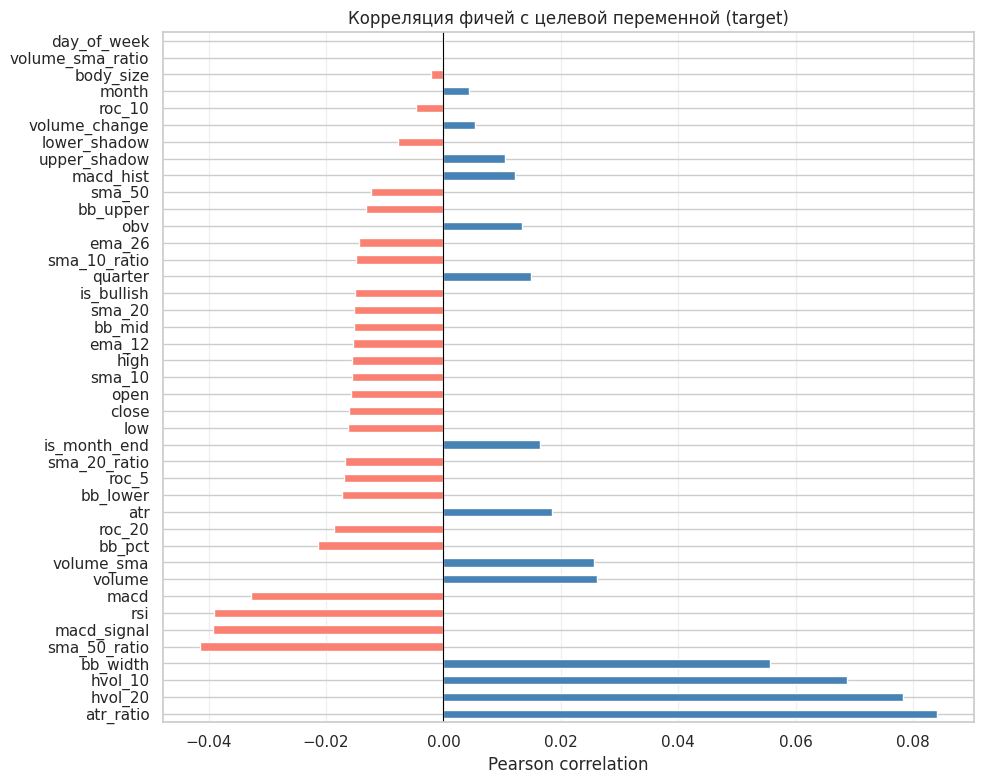


Топ-10 фичей по корреляции с таргетом:
atr_ratio       0.0841
hvol_20         0.0782
hvol_10         0.0688
bb_width        0.0556
sma_50_ratio   -0.0415
macd_signal    -0.0392
rsi            -0.0390
macd           -0.0328
volume          0.0261
volume_sma      0.0256


In [ ]:
# Корреляция фичей с таргетом
target_corr = (
    df[feature_cols + ["target"]]
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["steelblue" if v >= 0 else "salmon" for v in target_corr.values]
target_corr.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Корреляция фичей с целевой переменной (target)")
ax.set_xlabel("Pearson correlation")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_target_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nТоп-10 фичей по корреляции с таргетом:")
print(target_corr.head(10).to_string())

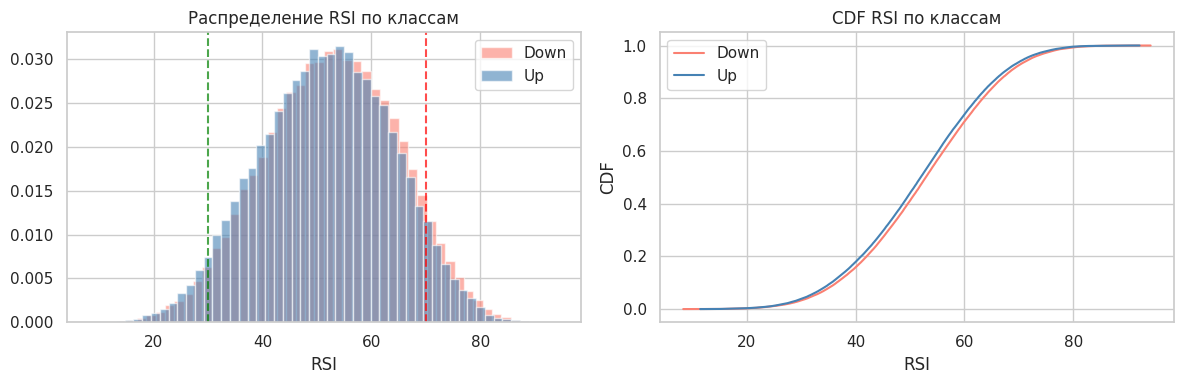

In [ ]:
# RSI: распределение по классам
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, color, label in [(0, "salmon", "Down"), (1, "steelblue", "Up")]:
    subset = df[df["target"] == cls]["rsi"].dropna()
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
    axes[1].plot(
        sorted(subset),
        np.linspace(0, 1, len(subset)),
        color=color, label=label, linewidth=1.5
    )

axes[0].set_title("Распределение RSI по классам")
axes[0].set_xlabel("RSI")
axes[0].legend()
axes[0].axvline(30, color="green", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[0].axvline(70, color="red", linestyle="--", alpha=0.7, label="Overbought (70)")

axes[1].set_title("CDF RSI по классам")
axes[1].set_xlabel("RSI")
axes[1].set_ylabel("CDF")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / "rsi_distribution_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

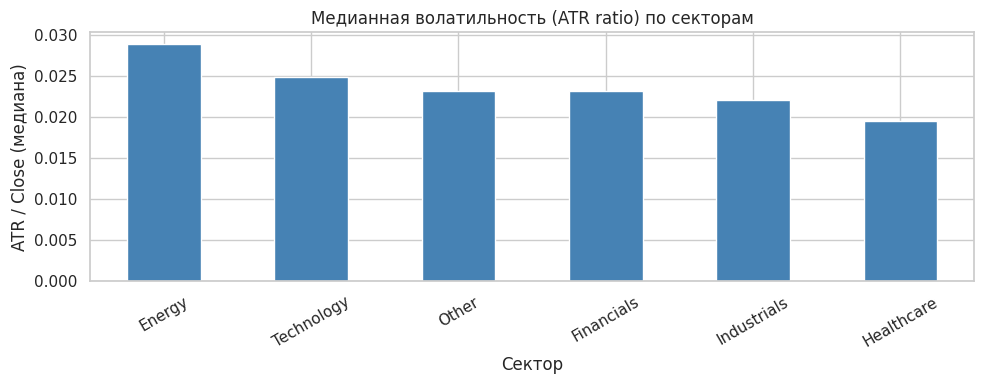

In [ ]:
# Волатильность по секторам
# Разбивка по секторам:
SECTORS = {
    "Technology":   ["AAPL", "MSFT", "GOOGL", "NVDA", "META", "AVGO", "ORCL", "CSCO", "ADBE", "CRM"],
    "Financials":   ["JPM", "BAC", "WFC", "GS", "MS", "BLK", "C", "AXP"],
    "Healthcare":   ["JNJ", "UNH", "PFE", "ABBV", "MRK", "TMO", "ABT"],
    "Energy":       ["XOM", "CVX", "COP", "SLB", "EOG"],
    "Industrials":  ["CAT", "HON", "UPS", "BA", "LMT"],
}

ticker_to_sector = {t: s for s, tickers in SECTORS.items() for t in tickers}
df["sector"] = df["ticker"].map(ticker_to_sector).fillna("Other")

sector_vol = df.groupby("sector")["atr_ratio"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sector_vol.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Медианная волатильность (ATR ratio) по секторам")
ax.set_ylabel("ATR / Close (медиана)")
ax.set_xlabel("Сектор")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "volatility_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Итоговая информация
print("""
=== Ключевые выводы EDA ===

1. ДАТАСЕТ
   - Строк:   {rows:,}
   - Фичей:   {features}
   - Тикеров: {tickers}
   - Период:  {start} — {end}

2. БАЛАНС КЛАССОВ
   - Down (0): {pct_0:.1f}%
   - Up   (1): {pct_1:.1f}%
   → Лёгкий дисбаланс, используем class_weight='balanced'

3. КОРРЕЛЯЦИИ С ТАРГЕТОМ
   - Самые значимые фичи: {top_features}
   - Большинство корреляций слабые (<0.1) — задача нетривиальная

4. МУЛЬТИКОЛЛИНЕАРНОСТЬ
   - Есть сильно коррелирующие пары (SMA разных периодов, EMA)
   - Деревья устойчивы к этому, для LR — учитываем

5. ВЫБРОСЫ
   - Экстремальные значения есть (кризисы, гэпы)
   - Обработаны в preprocessing.py через z-score > 5
""".format(
    rows=len(df),
    features=df.shape[1] - 2,
    tickers=df["ticker"].nunique(),
    start=df.index.min().date(),
    end=df.index.max().date(),
    pct_0=df["target"].value_counts(normalize=True)[0] * 100,
    pct_1=df["target"].value_counts(normalize=True)[1] * 100,
    top_features=target_corr.head(5).index.tolist(),
))


=== Ключевые выводы EDA ===

1. ДАТАСЕТ
   - Строк:   148,409
   - Фичей:   42
   - Тикеров: 102
   - Период:  2018-03-14 — 2023-12-21

2. БАЛАНС КЛАССОВ
   - Down (0): 57.7%
   - Up   (1): 42.3%
   → Лёгкий дисбаланс, используем class_weight='balanced'

3. КОРРЕЛЯЦИИ С ТАРГЕТОМ
   - Самые значимые фичи: ['atr_ratio', 'hvol_20', 'hvol_10', 'bb_width', 'sma_50_ratio']
   - Большинство корреляций слабые (<0.1) — задача нетривиальная

4. МУЛЬТИКОЛЛИНЕАРНОСТЬ
   - Есть сильно коррелирующие пары (SMA разных периодов, EMA)
   - Деревья устойчивы к этому, для LR — учитываем

5. ВЫБРОСЫ
   - Экстремальные значения есть (кризисы, гэпы)
   - Обработаны в preprocessing.py через z-score > 5



In [ ]:
print(X_train.columns.tolist())

['sma_10', 'sma_10_ratio', 'sma_20', 'sma_20_ratio', 'sma_50', 'sma_50_ratio', 'ema_12', 'ema_26', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'roc_5', 'roc_10', 'roc_20', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'atr', 'atr_ratio', 'hvol_10', 'hvol_20', 'obv', 'volume_sma_ratio', 'volume_change', 'body_size', 'upper_shadow', 'lower_shadow', 'is_bullish', 'day_of_week', 'month', 'quarter', 'is_month_end']


In [ ]:
# Очистка фичей на основе EDA

# Удаляем абсолютные значения цен
# абсолютные цены коррелируют с приблизительно 1.0 между собой и не несут
# предсказательной силы, лучше оставить только нормализованные версии (ratio, pct)
DROP = [
    "sma_10",    # остается sma_10_ratio
    "sma_20",    # остается sma_20_ratio
    "sma_50",    # остается sma_50_ratio
    "ema_12",    # заменяется macd
    "ema_26",    # заменяется macd
    "bb_upper",  # остается bb_pct и bb_width
    "bb_lower",  # остается bb_pct и bb_width
    "atr",       # остается atr_ratio (atr / close)
    "obv",       # абсолютный накопленный объём, зависит от точки старта
]

# Удаляем дублирующие фичи
# bb_mid = sma_20 (corr=1.0) — дубликат
DROP_DUPLICATES = [
    "bb_mid",
]

# Итоговый список к удалению
COLS_TO_DROP = DROP + DROP_DUPLICATES
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in df.columns]

df_clean = df.drop(columns=COLS_TO_DROP)

print(f"\nБыло фичей:  {len(df.columns) - 2}")   # -2: ticker, target
print(f"Стало фичей: {len(df_clean.columns) - 2}")
print(f"Удалено:     {len(COLS_TO_DROP)}")


Было фичей:  42
Стало фичей: 32
Удалено:     10


In [ ]:
# Финальный список фичей и их смысл

feature_cols_final = [
    c for c in df_clean.columns
    if c not in ["ticker", "target", "open", "high", "low", "close", "volume", "volume_sma", "sector"]
]

print("Финальные фичи\n")

FEATURE_DESCRIPTIONS = {
    # Трендовые (нормализованные)
    "sma_10_ratio":     "Цена / SMA(10) — насколько цена выше/ниже краткосрочного тренда",
    "sma_20_ratio":     "Цена / SMA(20) — среднесрочный тренд",
    "sma_50_ratio":     "Цена / SMA(50) — долгосрочный тренд",
    # Моментум
    "rsi":              "RSI(14) — перекупленность/перепроданность [0-100]",
    "macd":             "MACD = EMA(12) - EMA(26) — моментум тренда",
    "macd_signal":      "Сигнальная линия MACD",
    "macd_hist":        "Гистограмма MACD — сила сигнала",
    "roc_5":            "Изменение цены за 5 дней (%)",
    "roc_10":           "Изменение цены за 10 дней (%)",
    "roc_20":           "Изменение цены за 20 дней (%)",
    # Волатильность
    "bb_width":         "Ширина Bollinger Bands — уровень волатильности",
    "bb_pct":           "Позиция цены внутри Bollinger Bands [0-1]",
    "atr_ratio":        "ATR / Close — нормализованная волатильность",
    "hvol_10":          "Историческая волатильность за 10 дней (годовая)",
    "hvol_20":          "Историческая волатильность за 20 дней (годовая)",
    # Объём
    "volume_sma_ratio": "Объём / SMA(объём) — аномальный объём > 1.5",
    "volume_change":    "Изменение объёма день к дню (%)",
    # Свечи
    "body_size":        "Размер тела свечи (доля от диапазона)",
    "upper_shadow":     "Верхняя тень свечи",
    "lower_shadow":     "Нижняя тень свечи",
    "is_bullish":       "1 если close > open",
    # Время
    "day_of_week":      "День недели (0=пн, 4=пт)",
    "month":            "Месяц (1-12)",
    "quarter":          "Квартал (1-4)",
    "is_month_end":     "1 если последний торговый день месяца",
}

for col in feature_cols_final:
    desc = FEATURE_DESCRIPTIONS.get(col, "—")
    print(f"  {col:22s}  {desc}")

print(f"\nИтого фичей: {len(feature_cols_final)}")

Финальные фичи

  sma_10_ratio            Цена / SMA(10) — насколько цена выше/ниже краткосрочного тренда
  sma_20_ratio            Цена / SMA(20) — среднесрочный тренд
  sma_50_ratio            Цена / SMA(50) — долгосрочный тренд
  rsi                     RSI(14) — перекупленность/перепроданность [0-100]
  macd                    MACD = EMA(12) - EMA(26) — моментум тренда
  macd_signal             Сигнальная линия MACD
  macd_hist               Гистограмма MACD — сила сигнала
  roc_5                   Изменение цены за 5 дней (%)
  roc_10                  Изменение цены за 10 дней (%)
  roc_20                  Изменение цены за 20 дней (%)
  bb_width                Ширина Bollinger Bands — уровень волатильности
  bb_pct                  Позиция цены внутри Bollinger Bands [0-1]
  atr_ratio               ATR / Close — нормализованная волатильность
  hvol_10                 Историческая волатильность за 10 дней (годовая)
  hvol_20                 Историческая волатильность за 20 дней (г